In [1]:


# General Libraries
import sys
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import copy

# FNO Model Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from itertools import product

print("numpy:", np.__version__)
print("torch:", torch.__version__)

# Compatibility aliases for loading pickles created with NumPy 2.x
import numpy.core
import numpy.core.numeric
import numpy.core.multiarray
import numpy.core.umath

sys.modules["numpy._core"] = numpy.core
sys.modules["numpy._core.numeric"] = numpy.core.numeric
sys.modules["numpy._core.multiarray"] = numpy.core.multiarray
sys.modules["numpy._core.umath"] = numpy.core.umath 

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)



numpy: 1.26.4
torch: 2.2.1+cu121
device: cuda


In [2]:
# Set seed of notebook for reproducibility
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # More reproducible CUDA behavior
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(0)

bat_df = pd.read_pickle("data/bat_df.pkl")
print(bat_df.shape)

(124, 12)


In [3]:
# Splits from original paper
numBat1 = 41
numBat2 = 43
numBat3 = 40
numBat = numBat1 + numBat2 + numBat3

test_ind = np.hstack((np.arange(0, (numBat1 + numBat2), 2), 83))
train_ind = np.arange(1, (numBat1 + numBat2 - 1), 2)
secondary_test_ind = np.arange(numBat - numBat3, numBat)

train_df = bat_df.iloc[train_ind].reset_index(drop=True)
primary_test_df = bat_df.iloc[test_ind].reset_index(drop=True)
secondary_test_df = bat_df.iloc[secondary_test_ind].reset_index(drop=True)

print("train_df:", train_df.shape)
print("primary_test_df:", primary_test_df.shape)
print("secondary_test_df:", secondary_test_df.shape)

train_df: (41, 12)
primary_test_df: (43, 12)
secondary_test_df: (40, 12)


In [4]:
# Directly fix outlier QD: b1c18, cycle 40
idx = primary_test_df.index[primary_test_df["battery_id"] == "b1c18"][0]
QD = primary_test_df.at[idx, "QD"].copy()
QD[39] = 0.5 * (QD[38] + QD[40])   # cycle_idx 39 = cycle 40
primary_test_df.at[idx, "QD"] = QD

# Directly fix outlier QD: b1c0, cycle 12
idx = primary_test_df.index[primary_test_df["battery_id"] == "b1c0"][0]
QD = primary_test_df.at[idx, "QD"].copy()
QD[11] = 0.5 * (QD[10] + QD[12])   # cycle_idx 11 = cycle 12
primary_test_df.at[idx, "QD"] = QD

In [5]:
# BUILD GRU DATASET FROM RAW Qdlin CURVES
# Input per battery: ΔQdlin_k(V) = Qdlin_k(V) - Qdlin_10(V)
# Uses only cycles 20, 30, 40, ..., 100
# Output per battery: log10(cycle_life)

REF_IDX = 9        # cycle 10, zero-indexed
CYCLE_IDXS = list(range(19, 100, 5))   # cycles 20, 30, ..., 100
N_CYCLES = len(CYCLE_IDXS)
N_VOLTAGE = 1000

print("Using cycle numbers:", [i + 1 for i in CYCLE_IDXS])
print("N_CYCLES:", N_CYCLES)

def get_qdlin_1000(cyc):
    q = np.asarray(cyc["Qdlin"], dtype=float).squeeze()

    if q.shape[0] != N_VOLTAGE:
        return None

    return q

def build_fno_arrays(df, split_name):
    X_list = []
    y_list = []
    battery_ids = []

    for _, row in df.iterrows():

        cycles_dict = row["cycles"]

        # Need reference cycle 10
        if str(REF_IDX) not in cycles_dict:
            print(f"Skipping {row['battery_id']} in {split_name}: missing reference cycle 10")
            continue

        q_ref = get_qdlin_1000(cycles_dict[str(REF_IDX)])

        if q_ref is None:
            print(f"Skipping {row['battery_id']} in {split_name}: bad reference Qdlin shape")
            continue

        battery_tensor = []
        valid = True

        for cyc_idx in CYCLE_IDXS:

            if str(cyc_idx) not in cycles_dict:
                valid = False
                break

            q = get_qdlin_1000(cycles_dict[str(cyc_idx)])

            if q is None:
                valid = False
                break

            dq = q - q_ref
            battery_tensor.append(dq)

        if not valid:
            print(f"Skipping {row['battery_id']} in {split_name}: missing/bad Qdlin shape")
            continue

        # Shape: [selected_cycles, voltage]
        battery_tensor = np.stack(battery_tensor, axis=0)

        # Add channel dimension: [selected_cycles, voltage, channels]
        battery_tensor = battery_tensor[..., None]

        X_list.append(battery_tensor)
        y_list.append(np.log10(row["cycle_life"]))
        battery_ids.append(row["battery_id"])

    X = np.stack(X_list, axis=0).astype(np.float32)
    y = np.asarray(y_list, dtype=np.float32).reshape(-1, 1)

    print(split_name)
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    return X, y, battery_ids


X_train, y_train, train_ids = build_fno_arrays(train_df, "train")
X_primary, y_primary, primary_ids = build_fno_arrays(primary_test_df, "primary_test")
X_secondary, y_secondary, secondary_ids = build_fno_arrays(secondary_test_df, "secondary_test")

Using cycle numbers: [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
N_CYCLES: 17
train
X shape: (41, 17, 1000, 1)
y shape: (41, 1)
primary_test
X shape: (43, 17, 1000, 1)
y shape: (43, 1)
secondary_test
X shape: (40, 17, 1000, 1)
y shape: (40, 1)


In [6]:
# ============================================================
# GRU BATTERY LIFE PREDICTION
# USING RAW ΔQdlin(V) CURVES
#
# Input:
#   [cycles, voltage_points]
#
# Pipeline:
#   Curve Encoder (MLP)
#           ↓
#       GRU over cycles
#           ↓
#     Cycle Life Prediction
#
# ============================================================

# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# ============================================================
# INPUT SHAPES
# ============================================================

print("Train:", X_train.shape)
print("Primary:", X_primary.shape)
print("Secondary:", X_secondary.shape)

# Expected:
#
# X:
# [N, cycles, voltage, channels]
#
# Example:
# (124, 17, 1000, 1)

Using device: cuda
Train: (41, 17, 1000, 1)
Primary: (43, 17, 1000, 1)
Secondary: (40, 17, 1000, 1)


In [7]:
# ============================================================
# REMOVE CHANNEL DIMENSION
# ============================================================

X_train = X_train.squeeze(-1)
X_primary = X_primary.squeeze(-1)
X_secondary = X_secondary.squeeze(-1)

print("\nAfter squeeze:")
print("Train:", X_train.shape)

# ============================================================
# FEATURE-WISE NORMALIZATION
# ============================================================
#
# Normalize each voltage coordinate independently
#
# ============================================================

def scale_voltage_features(
    X_train,
    X_val,
    X_test=None
):

    n_voltage = X_train.shape[-1]

    scalers = []

    X_train_scaled = np.zeros_like(X_train)
    X_val_scaled = np.zeros_like(X_val)

    if X_test is not None:
        X_test_scaled = np.zeros_like(X_test)

    for v in range(n_voltage):

        scaler = StandardScaler()

        train_feat = X_train[:, :, v]

        scaler.fit(
            train_feat.reshape(-1, 1)
        )

        X_train_scaled[:, :, v] = (
            scaler.transform(
                train_feat.reshape(-1, 1)
            ).reshape(train_feat.shape)
        )

        val_feat = X_val[:, :, v]

        X_val_scaled[:, :, v] = (
            scaler.transform(
                val_feat.reshape(-1, 1)
            ).reshape(val_feat.shape)
        )

        if X_test is not None:

            test_feat = X_test[:, :, v]

            X_test_scaled[:, :, v] = (
                scaler.transform(
                    test_feat.reshape(-1, 1)
                ).reshape(test_feat.shape)
            )

        scalers.append(scaler)

    if X_test is not None:

        return (
            X_train_scaled,
            X_val_scaled,
            X_test_scaled,
            scalers
        )

    return (
        X_train_scaled,
        X_val_scaled,
        scalers
    )


After squeeze:
Train: (41, 17, 1000)


In [8]:
# ============================================================
# CURVE ENCODER + GRU MODEL
# ============================================================
#
# Per-cycle:
#   1000 voltage samples
#
# ↓ MLP encoder
#
# latent vector
#
# ↓ GRU over cycles
#
# prediction
#
# ============================================================

class CurveGRU(nn.Module):

    def __init__(
        self,
        voltage_points=1000,
        curve_latent_dim=128,
        hidden_size=128,
        num_layers=2,
        dropout=0.2
    ):

        super().__init__()

        # ============================================
        # Per-curve encoder
        # ============================================

        self.curve_encoder = nn.Sequential(

            nn.Linear(
                voltage_points,
                512
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                512,
                curve_latent_dim
            ),

            nn.ReLU()
        )

        # ============================================
        # GRU
        # ============================================

        self.gru = nn.GRU(
            input_size=curve_latent_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # ============================================
        # Regression head
        # ============================================

        self.regressor = nn.Sequential(

            nn.Dropout(dropout),

            nn.Linear(
                hidden_size,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                1
            )
        )

    def forward(self, x):

        # ============================================
        # x shape:
        # [batch, cycles, voltage]
        # ============================================

        B, T, V = x.shape

        # ============================================
        # Flatten cycles into batch dimension
        # ============================================

        x = x.reshape(
            B * T,
            V
        )

        # ============================================
        # Encode each curve
        # ============================================

        x = self.curve_encoder(x)

        # ============================================
        # Restore sequence structure
        # ============================================

        x = x.reshape(
            B,
            T,
            -1
        )

        # ============================================
        # GRU
        # ============================================

        out, _ = self.gru(x)

        # Final timestep
        out = out[:, -1, :]

        # ============================================
        # Regression
        # ============================================

        out = self.regressor(out)

        return out

In [9]:
# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_model(
    model,
    train_loader,
    val_loader,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=300,
    tol=1e-4
):

    criterion = nn.HuberLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_loss = np.inf
    best_state = None

    train_losses = []
    val_losses = []

    model.to(device)

    for epoch in range(epochs):

        # ====================================================
        # TRAIN
        # ====================================================

        model.train()

        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            preds = model(X_batch)

            loss = criterion(
                preds,
                y_batch
            )

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = (
            running_train_loss
            / len(train_loader)
        )

        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                preds = model(X_batch)

                loss = criterion(
                    preds,
                    y_batch
                )

                running_val_loss += loss.item()

        avg_val_loss = (
            running_val_loss
            / len(val_loader)
        )

        train_losses.append(
            avg_train_loss
        )

        val_losses.append(
            avg_val_loss
        )

        # ====================================================
        # EARLY STOPPING
        # ====================================================

        improvement = (
            best_val_loss
            - avg_val_loss
        )

        if improvement > tol:

            best_val_loss = avg_val_loss

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        if epoch % 20 == 0:

            print(
                f"Epoch {epoch:3d} | "
                f"Train {avg_train_loss:.6f} | "
                f"Val {avg_val_loss:.6f}"
            )

    model.load_state_dict(best_state)

    return model, train_losses, val_losses

In [10]:
# ============================================================
# MAPE FUNCTION
# ============================================================

def compute_mape(
    model,
    X_tensor,
    y_tensor
):

    model.eval()

    X_tensor = X_tensor.to(device)

    with torch.no_grad():

        preds_log = (
            model(X_tensor)
            .cpu()
            .numpy()
            .flatten()
        )

    preds = 10 ** preds_log

    y_true = (
        10 ** y_tensor
        .cpu()
        .numpy()
        .flatten()
    )

    mape = np.mean(
        np.abs(preds - y_true)
        / y_true
    ) * 100

    return mape

# ============================================================
# CROSS VALIDATION
# ============================================================

def cross_validate_model(
    config,
    X,
    y,
    n_splits=4
):

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    fold_mapes = []

    for fold, (train_idx, val_idx) in enumerate(
        kf.split(X)
    ):

        print(f"\nFold {fold+1}/{n_splits}")

        # ============================================
        # SPLIT
        # ============================================

        X_train_fold = X[train_idx]
        X_val_fold = X[val_idx]

        y_train_fold = y[train_idx]
        y_val_fold = y[val_idx]

        # ============================================
        # SCALE
        # ============================================

        (
            X_train_scaled,
            X_val_scaled,
            _
        ) = scale_voltage_features(
            X_train_fold,
            X_val_fold
        )

        # ============================================
        # TENSORS
        # ============================================

        X_train_tensor = torch.tensor(
            X_train_scaled,
            dtype=torch.float32
        )

        X_val_tensor = torch.tensor(
            X_val_scaled,
            dtype=torch.float32
        )

        y_train_tensor = torch.tensor(
            y_train_fold,
            dtype=torch.float32
        )

        y_val_tensor = torch.tensor(
            y_val_fold,
            dtype=torch.float32
        )

        # ============================================
        # DATALOADERS
        # ============================================

        train_loader = DataLoader(
            TensorDataset(
                X_train_tensor,
                y_train_tensor
            ),
            batch_size=16,
            shuffle=True
        )

        val_loader = DataLoader(
            TensorDataset(
                X_val_tensor,
                y_val_tensor
            ),
            batch_size=16,
            shuffle=False
        )

        # ============================================
        # MODEL
        # ============================================

        model = CurveGRU(
            voltage_points=X.shape[-1],
            curve_latent_dim=config["curve_latent_dim"],
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
            dropout=config["dropout"]
        )

        # ============================================
        # TRAIN
        # ============================================

        model, _, _ = train_model(
            model,
            train_loader,
            val_loader,
            lr=config["lr"],
            weight_decay=config["weight_decay"],
            epochs=config["epochs"],
            tol=config["tol"]
        )

        # ============================================
        # MAPE
        # ============================================

        fold_mape = compute_mape(
            model,
            X_val_tensor,
            y_val_tensor
        )

        print(
            f"Fold MAPE: "
            f"{fold_mape:.2f}%"
        )

        fold_mapes.append(
            fold_mape
        )

    return np.mean(fold_mapes)

In [11]:
# ============================================================
# HYPERPARAMETER SEARCH
# ============================================================

search_space = [

    {
        "curve_latent_dim": 64,
        "hidden_size": 64,
        "num_layers": 1,
        "dropout": 0.1,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "epochs": 200,
        "tol": 1e-4
    },

    {
        "curve_latent_dim": 128,
        "hidden_size": 128,
        "num_layers": 2,
        "dropout": 0.2,
        "lr": 5e-4,
        "weight_decay": 1e-4,
        "epochs": 300,
        "tol": 1e-4
    }
]

best_config = None
best_cv_mape = np.inf

for config in search_space:

    print("\n===================================")
    print(config)

    cv_mape = cross_validate_model(
        config,
        X_train,
        y_train
    )

    print(
        f"\nMean CV MAPE: "
        f"{cv_mape:.2f}%"
    )

    if cv_mape < best_cv_mape:

        best_cv_mape = cv_mape
        best_config = config

print("\nBEST CONFIG")
print(best_config)

print("\nBEST CV MAPE")
print(best_cv_mape)

# ============================================================
# FINAL SCALING
# ============================================================

(
    X_train_scaled,
    X_primary_scaled,
    X_secondary_scaled,
    _
) = scale_voltage_features(
    X_train,
    X_primary,
    X_secondary
)

# ============================================================
# FINAL TENSORS
# ============================================================

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_primary_tensor = torch.tensor(
    X_primary_scaled,
    dtype=torch.float32
)

X_secondary_tensor = torch.tensor(
    X_secondary_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)


{'curve_latent_dim': 64, 'hidden_size': 64, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0001, 'epochs': 200, 'tol': 0.0001}

Fold 1/4
Epoch   0 | Train 2.175617 | Val 1.788576
Epoch  20 | Train 0.028336 | Val 0.006518
Epoch  40 | Train 0.026642 | Val 0.002957
Epoch  60 | Train 0.021862 | Val 0.004267
Epoch  80 | Train 0.018697 | Val 0.003405
Epoch 100 | Train 0.014971 | Val 0.002474
Epoch 120 | Train 0.010859 | Val 0.002898
Epoch 140 | Train 0.009664 | Val 0.004348
Epoch 160 | Train 0.009077 | Val 0.007434
Epoch 180 | Train 0.010638 | Val 0.004152
Fold MAPE: 9.44%

Fold 2/4
Epoch   0 | Train 2.345445 | Val 2.253716
Epoch  20 | Train 0.026131 | Val 0.041538
Epoch  40 | Train 0.017097 | Val 0.020571
Epoch  60 | Train 0.013628 | Val 0.014824
Epoch  80 | Train 0.012098 | Val 0.015207
Epoch 100 | Train 0.007566 | Val 0.013254
Epoch 120 | Train 0.016718 | Val 0.015234
Epoch 140 | Train 0.012245 | Val 0.025737
Epoch 160 | Train 0.013817 | Val 0.015859
Epoch 180 | Train 0.

In [20]:
# ============================================================
# FINAL MODEL
# ============================================================

best_model = CurveGRU(
    voltage_points=X_train.shape[-1],
    curve_latent_dim=best_config["curve_latent_dim"],
    hidden_size=best_config["hidden_size"],
    num_layers=best_config["num_layers"],
    dropout=best_config["dropout"]
)

train_loader = DataLoader(
    TensorDataset(
        X_train_tensor,
        y_train_tensor
    ),
    batch_size=16,
    shuffle=True
)

best_model, train_losses, val_losses = train_model(
    best_model,
    train_loader,
    train_loader,
    lr=best_config["lr"],
    weight_decay=best_config["weight_decay"],
    epochs=800,
    tol=best_config["tol"]
)

# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict(
    model,
    X_tensor
):

    model.eval()

    X_tensor = X_tensor.to(device)

    with torch.no_grad():

        preds_log = (
            model(X_tensor)
            .cpu()
            .numpy()
            .flatten()
        )

    return preds_log

Epoch   0 | Train 2.190550 | Val 1.806665
Epoch  20 | Train 0.019405 | Val 0.011801
Epoch  40 | Train 0.018919 | Val 0.005579
Epoch  60 | Train 0.017657 | Val 0.002781
Epoch  80 | Train 0.012571 | Val 0.003947
Epoch 100 | Train 0.015636 | Val 0.004917
Epoch 120 | Train 0.014168 | Val 0.003006
Epoch 140 | Train 0.009950 | Val 0.005485
Epoch 160 | Train 0.008422 | Val 0.001624
Epoch 180 | Train 0.007988 | Val 0.002910
Epoch 200 | Train 0.011711 | Val 0.002027
Epoch 220 | Train 0.010866 | Val 0.001941
Epoch 240 | Train 0.011863 | Val 0.001347
Epoch 260 | Train 0.009785 | Val 0.001525
Epoch 280 | Train 0.007950 | Val 0.001148
Epoch 300 | Train 0.006498 | Val 0.004369
Epoch 320 | Train 0.008461 | Val 0.005133
Epoch 340 | Train 0.009584 | Val 0.001660
Epoch 360 | Train 0.007570 | Val 0.001778
Epoch 380 | Train 0.011450 | Val 0.001885
Epoch 400 | Train 0.009016 | Val 0.001062
Epoch 420 | Train 0.008760 | Val 0.002014
Epoch 440 | Train 0.008233 | Val 0.002196
Epoch 460 | Train 0.008272 | Val 0

,split,rmse_cycles,mean_percent_error
0,validation_cv,NaN,15.306225
1,train,39.111546,4.347502
2,primary_test,132.474426,14.801729
3,secondary_test,272.819336,18.337764


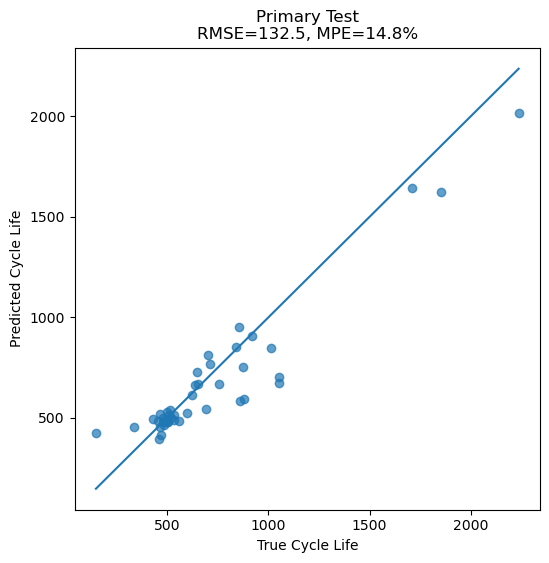

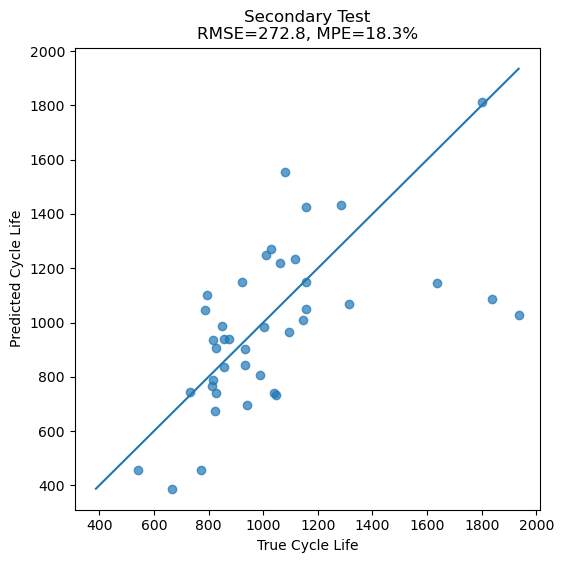

In [21]:
# ============================================================
# PREDICTIONS
# ============================================================

train_pred_log = predict(
    best_model,
    X_train_tensor
)

primary_pred_log = predict(
    best_model,
    X_primary_tensor
)

secondary_pred_log = predict(
    best_model,
    X_secondary_tensor
)

train_pred = 10 ** train_pred_log
primary_pred = 10 ** primary_pred_log
secondary_pred = 10 ** secondary_pred_log

train_true = 10 ** y_train.flatten()
primary_true = 10 ** y_primary.flatten()
secondary_true = 10 ** y_secondary.flatten()

# ============================================================
# METRICS
# ============================================================

train_rmse = np.sqrt(
    mean_squared_error(
        train_true,
        train_pred
    )
)

primary_rmse = np.sqrt(
    mean_squared_error(
        primary_true,
        primary_pred
    )
)

secondary_rmse = np.sqrt(
    mean_squared_error(
        secondary_true,
        secondary_pred
    )
)

train_mpe = np.mean(
    np.abs(train_pred - train_true)
    / train_true
) * 100

primary_mpe = np.mean(
    np.abs(primary_pred - primary_true)
    / primary_true
) * 100

secondary_mpe = np.mean(
    np.abs(secondary_pred - secondary_true)
    / secondary_true
) * 100

# ============================================================
# SUMMARY TABLE
# ============================================================

summary_df = pd.DataFrame({

    "split": [
        "validation_cv",
        "train",
        "primary_test",
        "secondary_test"
    ],

    "rmse_cycles": [
        np.nan,
        train_rmse,
        primary_rmse,
        secondary_rmse
    ],

    "mean_percent_error": [
        best_cv_mape,
        train_mpe,
        primary_mpe,
        secondary_mpe
    ]
})

display(summary_df)

# ============================================================
# PRIMARY TEST PLOT
# ============================================================

plt.figure(figsize=(6,6))

plt.scatter(
    primary_true,
    primary_pred,
    alpha=0.7
)

lims = [
    min(
        primary_true.min(),
        primary_pred.min()
    ),
    max(
        primary_true.max(),
        primary_pred.max()
    )
]

plt.plot(lims, lims)

plt.xlabel("True Cycle Life")
plt.ylabel("Predicted Cycle Life")

plt.title(
    f"Primary Test\n"
    f"RMSE={primary_rmse:.1f}, "
    f"MPE={primary_mpe:.1f}%"
)

plt.show()

# ============================================================
# SECONDARY TEST PLOT
# ============================================================

plt.figure(figsize=(6,6))

plt.scatter(
    secondary_true,
    secondary_pred,
    alpha=0.7
)

lims = [
    min(
        secondary_true.min(),
        secondary_pred.min()
    ),
    max(
        secondary_true.max(),
        secondary_pred.max()
    )
]

plt.plot(lims, lims)

plt.xlabel("True Cycle Life")
plt.ylabel("Predicted Cycle Life")

plt.title(
    f"Secondary Test\n"
    f"RMSE={secondary_rmse:.1f}, "
    f"MPE={secondary_mpe:.1f}%"
)

plt.show()